In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns

import dask.dataframe as dd
from pathlib import Path
import glob
import re

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")
sys.path.append("../src/tests")

In [3]:
import clustering as clstr
import bout.assembly as bt
import plot as bt_plt
import test_activity_metric_functions as test_actvt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline
from core import SITE_NAMES, FREQUENCY_COLOR_MAPPINGS

from cli import get_file_paths
import pipeline

In [93]:
def get_between_bout_intervals_in_secs(bout_metrics_group):
    raw_intervals = bout_metrics_group['start_time_of_bout'] - bout_metrics_group['end_time_of_bout'].shift(1)
    bout_metrics_group.insert(0, 'between_bout_intervals', raw_intervals)
    bout_metrics_group['ref_time'] = pd.DatetimeIndex(bout_metrics_group['start_time_of_bout'])
    bm_group_df = bout_metrics_group.set_index('ref_time')
    first_calls_per_day = bm_group_df.resample('D').first()['start_time_of_bout']
    first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)
    bm_group_df.loc[first_valid_calls_per_day, 'between_bout_intervals'] = np.NaN

    intervals = bm_group_df[~bm_group_df['between_bout_intervals'].isna()]['between_bout_intervals'].values.astype('float64')
    valid_intervals = intervals[~(np.isnan(intervals))&~(intervals==0)]
    BB_intervals_s = valid_intervals/1e9
    return BB_intervals_s

def get_valid_ipis_ms(location_sum_df):
    """
    Gets the IPIs (Inter-Pulse Intervals) for a given location and frequency group
    using the 2022_bd2_summary files stored in data.

    Ignores IPIs generated for the first call of every date since we only want to consider intervals within nights.

    Returns a numpy array of IPIs in milliseconds.
    """

    intervals = pd.to_datetime(location_sum_df['call_start_time']) - pd.to_datetime(location_sum_df['call_end_time']).shift(1)
    location_sum_df.insert(0, 'time_from_prev_call_end_time', intervals)

    location_sum_df['ref_time'] = pd.DatetimeIndex(location_sum_df['call_start_time'])
    location_sum_df = location_sum_df.set_index('ref_time')

    first_calls_per_day = location_sum_df.resample('D').first()['call_start_time']
    first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)
    location_sum_df.loc[first_valid_calls_per_day, 'time_from_prev_call_end_time'] = pd.NaT

    intervals = location_sum_df[~location_sum_df['time_from_prev_call_end_time'].isna()]['time_from_prev_call_end_time'].values.astype('float64')
    valid_intervals = intervals[~(np.isnan(intervals))&~(intervals<=0)]
    ipis_ms = valid_intervals/1e6

    return ipis_ms

In [39]:
site_key = 'Central'
freq_key = 'LF'
data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['cur_dc_tag'] = '30of30'
data_params['index_time_block_in_secs'] = 5
data_params['cycle_length'] = int(data_params['cur_dc_tag'].split('of')[-1])
data_params['time_on'] = int(data_params['cur_dc_tag'].split('of')[0])
data_params['time_on_in_secs'] = 60*data_params['time_on']
file_paths = get_file_paths(data_params)

location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
peak_frequencies_sorted_group = location_df["peak_frequency"].values
call_ipis_ms_group = get_valid_ipis_ms(location_df.copy())
call_ipis_ms_group = call_ipis_ms_group[call_ipis_ms_group<1000]

bout_params = bt.get_bout_params_from_location(location_df, data_params)
dc_applied_df = ss.simulate_dutycycle_on_detections(location_df.copy(), data_params)
bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df, data_params, bout_params)
bout_metrics_group = bout_metrics[bout_metrics['freq_group']==freq_key].copy()
bout_durations_sorted_group = bout_metrics_group["bout_duration_in_secs"].values

bbis_s_group = get_between_bout_intervals_in_secs(bout_metrics_group)

In [6]:
bout_metrics_group = bout_metrics[bout_metrics['freq_group']==freq_key].copy()

In [61]:
test_df = location_df.sort_values('call_start_time').copy()
intervals = pd.to_datetime(test_df['call_start_time']) - pd.to_datetime(test_df['call_end_time']).shift(1)
test_df.insert(0, 'time_from_prev_call_end_time', intervals)

test_df['ref_time'] = pd.DatetimeIndex(test_df['call_start_time'])
test_df = test_df.set_index('ref_time')

first_calls_per_day = test_df.resample('D').first()['call_start_time']
first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)
test_df.loc[first_valid_calls_per_day, 'time_from_prev_call_end_time'] = pd.NaT
test_df

,time_from_prev_call_end_time,index_in_file,peak_frequency,index_in_summary,input_file_dt,freq_group,call_start_time,call_end_time,start_time,end_time,...,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
ref_time,,,,,,,,,,,,,,,,,,,,,
2022-07-26 01:04:33.481500,NaT,0,24000.0,0,2022-07-26 01:00:00,LF,2022-07-26 01:04:33.481500000,2022-07-26 01:04:33.498400000,273.4815,273.4984,...,Echolocation,Nyctalus leisleri,0.666,0.685,-1,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Central Pond,recover-20220728,8,1795.0
2022-07-26 02:03:07.694500,0 days 00:58:34.196100,0,24000.0,1,2022-07-26 02:00:00,LF,2022-07-26 02:03:07.694500000,2022-07-26 02:03:07.713700000,187.6945,187.7137,...,Echolocation,Nyctalus leisleri,0.518,0.555,-1,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Central Pond,recover-20220728,8,1795.0
2022-07-26 03:00:43.713500,0 days 00:57:35.999800,0,22080.0,2,2022-07-26 03:00:00,LF,2022-07-26 03:00:43.713500000,2022-07-26 03:00:43.734000000,43.7135,43.7340,...,Echolocation,Nyctalus leisleri,0.709,0.724,-1,/mnt/ubna_data_01/recover-20220728/UBNA_008/20...,Central Pond,recover-20220728,UBNA_008,NaN
2022-07-26 04:00:39.600500,0 days 00:59:55.866500,0,24000.0,3,2022-07-26 04:00:00,LF,2022-07-26 04:00:39.600500000,2022-07-26 04:00:39.617300000,39.6005,39.6173,...,Echolocation,Nyctalus leisleri,0.577,0.595,-1,/mnt/ubna_data_01/recover-20220728/UBNA_008/20...,Central Pond,recover-20220728,UBNA_008,NaN
2022-07-26 04:33:06.203500,0 days 00:32:26.586200,0,24000.0,4,2022-07-26 04:30:00,LF,2022-07-26 04:33:06.203500000,2022-07-26 04:33:06.218400000,186.2035,186.2184,...,Echolocation,Nyctalus leisleri,0.381,0.551,-1,/mnt/ubna_data_01/recover-20220728/UBNA_008/20...,Central Pond,recover-20220728,UBNA_008,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-17 07:56:19.137500,0 days 00:00:00.336700,19,25920.0,415022,2022-10-17 07:30:00,LF,2022-10-17 07:56:19.137500000,2022-10-17 07:56:19.153900000,1579.1375,1579.1539,...,Echolocation,Nyctalus leisleri,0.399,0.566,-1,/mnt/ubna_data_02/recover-20221017/UBNA_009/20...,Central Pond,recover-20221017,9,NaN
2022-10-17 07:56:19.372500,0 days 00:00:00.218600,20,26880.0,415023,2022-10-17 07:30:00,LF,2022-10-17 07:56:19.372500000,2022-10-17 07:56:19.386300000,1579.3725,1579.3863,...,Echolocation,Nyctalus leisleri,0.440,0.519,-1,/mnt/ubna_data_02/recover-20221017/UBNA_009/20...,Central Pond,recover-20221017,9,NaN
2022-10-17 07:56:19.595500,0 days 00:00:00.209200,21,27840.0,415024,2022-10-17 07:30:00,LF,2022-10-17 07:56:19.595500000,2022-10-17 07:56:19.607700000,1579.5955,1579.6077,...,Echolocation,Nyctalus leisleri,0.379,0.569,-1,/mnt/ubna_data_02/recover-20221017/UBNA_009/20...,Central Pond,recover-20221017,9,NaN


In [63]:
test_subset = test_df[~test_df['time_from_prev_call_end_time'].isna()]

In [67]:
problems = test_subset[test_subset['time_from_prev_call_end_time'].values.astype('float64')<0]
problems

,time_from_prev_call_end_time,index_in_file,peak_frequency,index_in_summary,input_file_dt,freq_group,call_start_time,call_end_time,start_time,end_time,...,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
ref_time,,,,,,,,,,,,,,,,,,,,,
2022-07-31 06:58:28.588500000,-1 days +23:59:59.998200,195,27840.0,29937,2022-07-31 06:30:00,LF,2022-07-31 06:58:28.588500000,2022-07-31 06:58:28.598500000,1708.5885,1708.5985,...,Echolocation,Nyctalus leisleri,0.327,0.527,-1,/mnt/ubna_data_01/recover-20220801/UBNA_005/20...,Central Pond,recover-20220801,UBNA_005,NaN
2022-08-02 06:34:31.268500000,-1 days +23:59:59.997500,357,29760.0,40766,2022-08-02 06:30:00,LF,2022-08-02 06:34:31.268500000,2022-08-02 06:34:31.280000000,271.2685,271.2800,...,Echolocation,Eptesicus serotinus,0.329,0.575,-1,/mnt/ubna_data_01/recover-20220804/UBNA_003/20...,Central Pond,recover-20220804,UBNA_003,NaN
2022-08-06 07:57:11.171500000,-1 days +23:59:59.996900,281,25920.0,83139,2022-08-06 07:30:00,LF,2022-08-06 07:57:11.171500000,2022-08-06 07:57:11.182000000,1631.1715,1631.1820,...,Echolocation,Eptesicus serotinus,0.289,0.527,-1,/mnt/ubna_data_01/recover-20220808/UBNA_012/20...,Central Pond,recover-20220808,UBNA_012,NaN
2022-08-08 04:38:27.540500000,-1 days +23:59:59.999900,525,25920.0,93090,2022-08-08 04:30:00,LF,2022-08-08 04:38:27.540500000,2022-08-08 04:38:27.550200000,507.5405,507.5502,...,Echolocation,Eptesicus serotinus,0.170,0.510,-1,/mnt/ubna_data_01/recover-20220808/UBNA_012/20...,Central Pond,recover-20220808,UBNA_012,NaN
2022-08-12 04:37:14.244500000,-1 days +23:59:59.999700,344,26880.0,119678,2022-08-12 04:30:00,LF,2022-08-12 04:37:14.244500000,2022-08-12 04:37:14.257299999,434.2445,434.2573,...,Echolocation,Nyctalus leisleri,0.252,0.590,-1,/mnt/ubna_data_01/recover-20220815/UBNA_008/20...,Central Pond,recover-20220815,UBNA_008,NaN
2022-08-13 05:35:51.889500000,-1 days +23:59:59.998400,584,27840.0,140740,2022-08-13 05:30:00,LF,2022-08-13 05:35:51.889500000,2022-08-13 05:35:51.901400000,351.8895,351.9014,...,Echolocation,Nyctalus leisleri,0.245,0.556,-1,/mnt/ubna_data_01/recover-20220815/UBNA_008/20...,Central Pond,recover-20220815,UBNA_008,NaN
2022-08-27 03:46:08.517499999,-1 days +23:59:59.999900,327,26880.0,257132,2022-08-27 03:30:00,LF,2022-08-27 03:46:08.517499999,2022-08-27 03:46:08.530300000,968.5175,968.5303,...,Echolocation,Eptesicus serotinus,0.255,0.534,-1,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,Central Pond,recover-20220828,UBNA_010,NaN
2022-09-03 03:47:40.699500000,-1 days +23:59:59.999300,1776,26880.0,309835,2022-09-03 03:30:00,LF,2022-09-03 03:47:40.699500000,2022-09-03 03:47:40.712700000,1060.6995,1060.7127,...,Echolocation,Nyctalus leisleri,0.364,0.600,-1,/mnt/ubna_data_02/recover-20220905/UBNA_009/20...,Central Pond,recover-20220905,9,NaN
2022-09-12 04:19:32.004500000,-1 days +23:59:59.996800,1166,25920.0,346429,2022-09-12 04:00:00,LF,2022-09-12 04:19:32.004500000,2022-09-12 04:19:32.020900000,1172.0045,1172.0209,...,Echolocation,Nyctalus leisleri,0.492,0.513,-1,/mnt/ubna_data_02/recover-20220912/UBNA_009/20...,Central Pond,recover-20220912,9,NaN


In [88]:
bucket_df = pd.DataFrame()
for i, row in problems.iterrows():
    points_of_interest = test_subset.loc[(test_subset['input_file']==row.input_file)&((test_subset['index_in_file']>=row.index_in_file-1) & (test_subset['index_in_file']<=row.index_in_file+1))]
    bucket_df = pd.concat([bucket_df, points_of_interest])

In [89]:
bucket_df

,time_from_prev_call_end_time,index_in_file,peak_frequency,index_in_summary,input_file_dt,freq_group,call_start_time,call_end_time,start_time,end_time,...,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
ref_time,,,,,,,,,,,,,,,,,,,,,
2022-07-31 06:58:28.575500000,0 days 00:00:00.061400,194,23040.0,29936,2022-07-31 06:30:00,LF,2022-07-31 06:58:28.575500000,2022-07-31 06:58:28.590300000,1708.5755,1708.5903,...,Echolocation,Nyctalus leisleri,0.596,0.618,-1,/mnt/ubna_data_01/recover-20220801/UBNA_005/20...,Central Pond,recover-20220801,UBNA_005,NaN
2022-07-31 06:58:28.588500000,-1 days +23:59:59.998200,195,27840.0,29937,2022-07-31 06:30:00,LF,2022-07-31 06:58:28.588500000,2022-07-31 06:58:28.598500000,1708.5885,1708.5985,...,Echolocation,Nyctalus leisleri,0.327,0.527,-1,/mnt/ubna_data_01/recover-20220801/UBNA_005/20...,Central Pond,recover-20220801,UBNA_005,NaN
2022-07-31 06:58:28.660500000,0 days 00:00:00.062000,196,29760.0,29938,2022-07-31 06:30:00,LF,2022-07-31 06:58:28.660500000,2022-07-31 06:58:28.669500000,1708.6605,1708.6695,...,Echolocation,Nyctalus leisleri,0.454,0.661,-1,/mnt/ubna_data_01/recover-20220801/UBNA_005/20...,Central Pond,recover-20220801,UBNA_005,NaN
2022-08-02 06:34:31.256500000,0 days 00:00:00.102000,356,24960.0,40765,2022-08-02 06:30:00,LF,2022-08-02 06:34:31.256500000,2022-08-02 06:34:31.271000000,271.2565,271.2710,...,Echolocation,Nyctalus leisleri,0.405,0.510,-1,/mnt/ubna_data_01/recover-20220804/UBNA_003/20...,Central Pond,recover-20220804,UBNA_003,NaN
2022-08-02 06:34:31.268500000,-1 days +23:59:59.997500,357,29760.0,40766,2022-08-02 06:30:00,LF,2022-08-02 06:34:31.268500000,2022-08-02 06:34:31.280000000,271.2685,271.2800,...,Echolocation,Eptesicus serotinus,0.329,0.575,-1,/mnt/ubna_data_01/recover-20220804/UBNA_003/20...,Central Pond,recover-20220804,UBNA_003,NaN
2022-08-02 06:34:31.408500000,0 days 00:00:00.128500,358,29760.0,40767,2022-08-02 06:30:00,LF,2022-08-02 06:34:31.408500000,2022-08-02 06:34:31.417900000,271.4085,271.4179,...,Echolocation,Nyctalus leisleri,0.395,0.714,-1,/mnt/ubna_data_01/recover-20220804/UBNA_003/20...,Central Pond,recover-20220804,UBNA_003,NaN
2022-08-06 07:57:11.163500000,0 days 00:00:00.096800001,280,23040.0,83138,2022-08-06 07:30:00,LF,2022-08-06 07:57:11.163500000,2022-08-06 07:57:11.174600000,1631.1635,1631.1746,...,Echolocation,Nyctalus noctula,0.295,0.602,-1,/mnt/ubna_data_01/recover-20220808/UBNA_012/20...,Central Pond,recover-20220808,UBNA_012,NaN
2022-08-06 07:57:11.171500000,-1 days +23:59:59.996900,281,25920.0,83139,2022-08-06 07:30:00,LF,2022-08-06 07:57:11.171500000,2022-08-06 07:57:11.182000000,1631.1715,1631.1820,...,Echolocation,Eptesicus serotinus,0.289,0.527,-1,/mnt/ubna_data_01/recover-20220808/UBNA_012/20...,Central Pond,recover-20220808,UBNA_012,NaN
2022-08-06 07:57:11.411500000,0 days 00:00:00.229500,282,22080.0,83140,2022-08-06 07:30:00,LF,2022-08-06 07:57:11.411500000,2022-08-06 07:57:11.425100000,1631.4115,1631.4251,...,Echolocation,Nyctalus noctula,0.465,0.631,-1,/mnt/ubna_data_01/recover-20220808/UBNA_012/20...,Central Pond,recover-20220808,UBNA_012,NaN


In [91]:
intervals = test_df[~test_df['time_from_prev_call_end_time'].isna()]['time_from_prev_call_end_time'].values.astype('float64')
valid_intervals = intervals[~(np.isnan(intervals))&~(intervals<=0)]
ipis_ms = valid_intervals.astype('float32')/1e6
ipis_ms

array([3.5141960e+06, 3.4559998e+06, 3.5958665e+06, ..., 2.0920000e+02,
       2.1380000e+02, 4.4129999e+02], dtype=float32)

In [92]:
ipis_ms.min()

0.2

In [115]:
bout_durations_groups = []
site_bout_labels = []
freq_group_bout_labels = []

bbis_in_secs_groups = []
site_bout_bbi_labels = []
freq_group_bout_bbi_labels = []

peak_frequencies_groups = []
site_call_freq_labels = []
freq_group_call_freq_labels = []

call_ipis_ms_groups = []
site_call_ipis_labels = []
freq_group_call_ipis_labels = []
for site_key in ['Carp', 'Central', 'Foliage', 'Telephone']:
    for i, freq_key in enumerate(['LF', 'HF']):
        data_params = dict()
        data_params['site_tag'] = site_key
        data_params['type_tag'] = freq_key
        data_params['detector_tag'] = 'bd2'
        data_params['assembly_type'] = 'kmeans'
        data_params['recording_start'] = '00:00'
        data_params['recording_end'] = '16:00'
        data_params['cur_dc_tag'] = '30of30'
        data_params['index_time_block_in_secs'] = 5
        data_params['cycle_length'] = int(data_params['cur_dc_tag'].split('of')[-1])
        data_params['time_on'] = int(data_params['cur_dc_tag'].split('of')[0])
        data_params['time_on_in_secs'] = 60*data_params['time_on']
        file_paths = get_file_paths(data_params)

        location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
        peak_frequencies_sorted_group = location_df["peak_frequency"].values
        call_ipis_ms_group = get_valid_ipis_ms(location_df.copy())
        call_ipis_ms_group = call_ipis_ms_group[(call_ipis_ms_group<1000)&(call_ipis_ms_group>10)]
        call_ipis_ms_groups += [call_ipis_ms_group]
        site_call_ipis_labels += [f'{SITE_NAMES[site_key]}'] * (len(call_ipis_ms_group))
        freq_group_call_ipis_labels += [f'{freq_key}'] * (len(call_ipis_ms_group))

        peak_frequencies_groups += [peak_frequencies_sorted_group]
        site_call_freq_labels += [f'{SITE_NAMES[site_key]}'] * (len(peak_frequencies_sorted_group))
        freq_group_call_freq_labels += [f'{freq_key}'] * (len(peak_frequencies_sorted_group))
        
        bout_params = bt.get_bout_params_from_location(location_df, data_params)
        dc_applied_df = ss.simulate_dutycycle_on_detections(location_df.copy(), data_params)
        bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df, data_params, bout_params)
        bout_metrics_group = bout_metrics[bout_metrics['freq_group']==freq_key].copy()
        bout_durations_sorted_group = bout_metrics_group["bout_duration_in_secs"].values
        bout_durations_groups += [bout_durations_sorted_group]
        site_bout_labels += [f'{SITE_NAMES[site_key]}'] * (len(bout_durations_sorted_group))
        freq_group_bout_labels += [f'{freq_key}'] * (len(bout_durations_sorted_group))

        bbis_s_group = get_between_bout_intervals_in_secs(bout_metrics_group)
        bbis_in_secs_groups += [bbis_s_group]
        site_bout_bbi_labels += [f'{SITE_NAMES[site_key]}'] * (len(bbis_s_group))
        freq_group_bout_bbi_labels += [f'{freq_key}'] * (len(bbis_s_group))

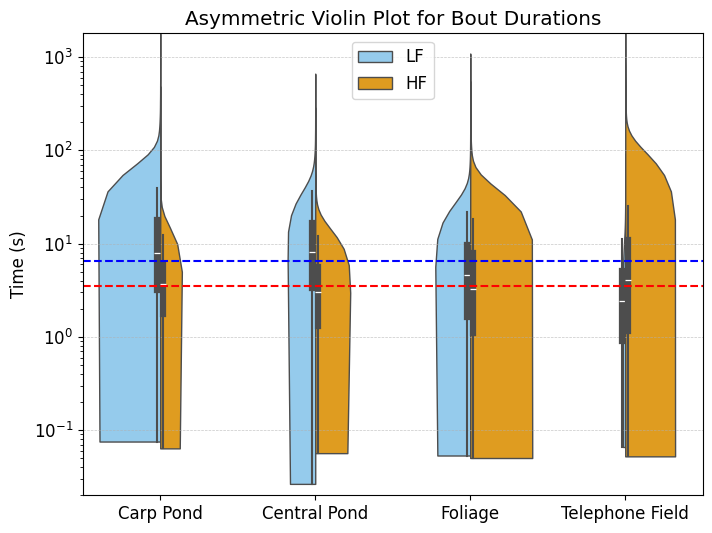

In [153]:
data = pd.DataFrame({
                    'Durations': np.concatenate(bout_durations_groups),
                    'Site names': site_bout_labels,
                    'Groups': freq_group_bout_labels
                    })

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 12})

sns.violinplot(
    data=data, x='Site names', y='Durations', hue='Groups',
    inner='box', split=True, linewidth=1, width=0.8,
    density_norm='count', bw_method=0.8, cut=0, palette=FREQUENCY_COLOR_MAPPINGS
)

plt.yscale('log')
plt.ylim(2e-2, 1800)
plt.ylabel('Time (s)')
plt.xlabel('')
plt.title('Asymmetric Violin Plot for Bout Durations')
plt.grid(which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper center')
plt.axhline(y=data[data['Groups']=='HF']['Durations'].median(), linestyle='dashed', color='red', label='Median HF duration')
plt.axhline(y=data[data['Groups']=='LF']['Durations'].median(), linestyle='dashed', color='blue', label='Median LF duration')

plt.show()

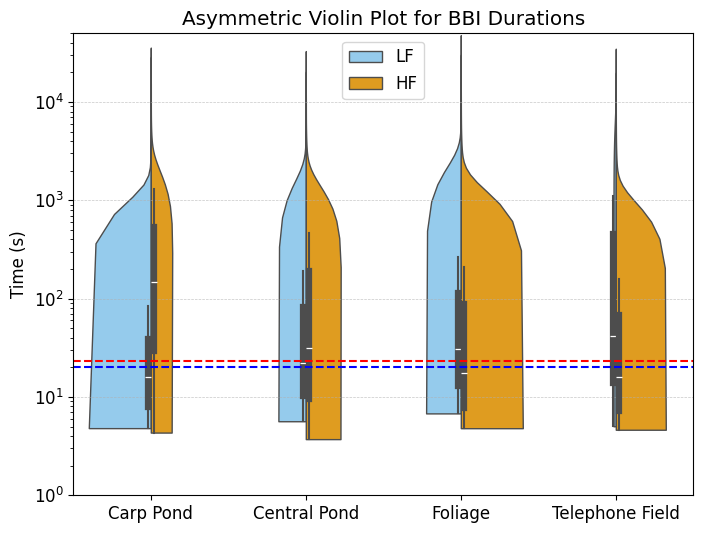

In [141]:
data = pd.DataFrame({
                    'BBI Durations': np.concatenate(bbis_in_secs_groups),
                    'Site names': site_bout_bbi_labels,
                    'Groups': freq_group_bout_bbi_labels
                    })

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 12})

sns.violinplot(
    data=data, x='Site names', y='BBI Durations', hue='Groups',
    inner='box', split=True, linewidth=1, width=0.8,
    density_norm='count', bw_method=1, cut=0, palette=FREQUENCY_COLOR_MAPPINGS
)

plt.yscale('log')
plt.ylim(1, 50000)
plt.ylabel('Time (s)')
plt.xlabel('')
plt.title('Asymmetric Violin Plot for BBI Durations')
plt.grid(which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper center')
plt.axhline(y=data[data['Groups']=='HF']['BBI Durations'].median(), linestyle='dashed', color='red', label='Median HF BBI duration')
plt.axhline(y=data[data['Groups']=='LF']['BBI Durations'].median(), linestyle='dashed', color='blue', label='Median LF BBI duration')

plt.show()

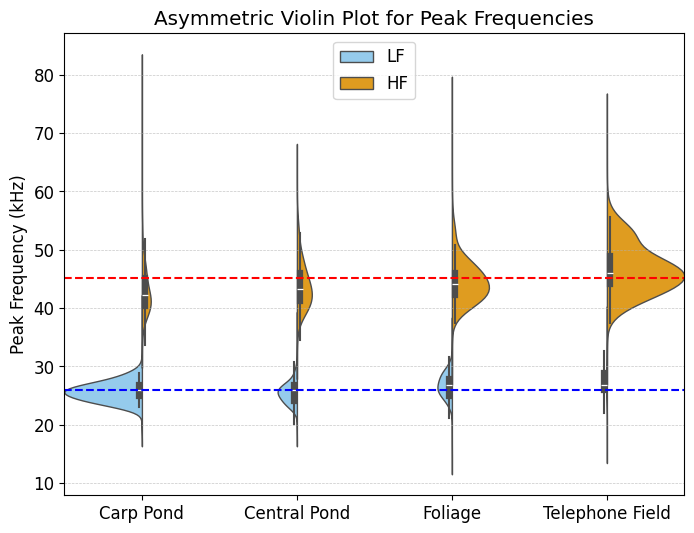

In [143]:
data = pd.DataFrame({
                    'Peak Frequencies': np.concatenate(peak_frequencies_groups)/1e3,
                    'Site names': site_call_freq_labels,
                    'Groups': freq_group_call_freq_labels
                    })

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 12})

sns.violinplot(
    data=data, x='Site names', y='Peak Frequencies', hue='Groups',
    inner='box', split=True, linewidth=1, width=1,
    density_norm='count', bw_method=0.5, cut=0, palette=FREQUENCY_COLOR_MAPPINGS
)

plt.ylabel('Peak Frequency (kHz)')
plt.xlabel('')
plt.title('Asymmetric Violin Plot for Peak Frequencies')
plt.grid(which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper center')
plt.axhline(y=data[data['Groups']=='HF']['Peak Frequencies'].median(), linestyle='dashed', color='red', label='Median HF peak frequency')
plt.axhline(y=data[data['Groups']=='LF']['Peak Frequencies'].median(), linestyle='dashed', color='blue', label='Median LF peak frequency')

plt.show()

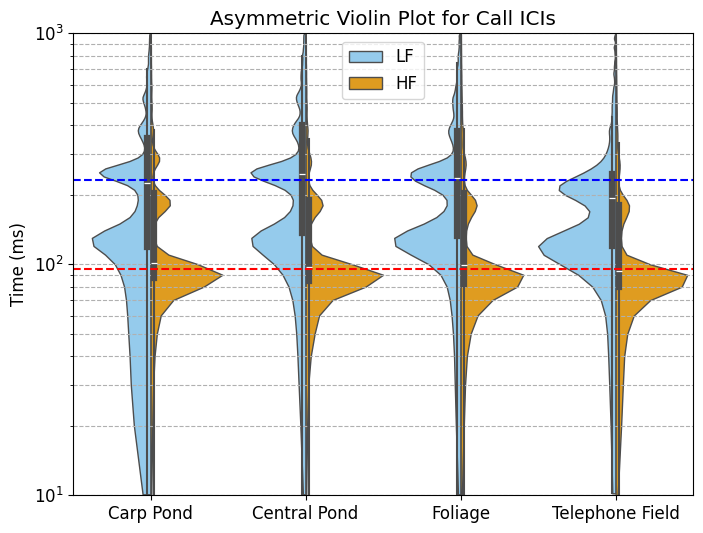

In [144]:
data = pd.DataFrame({
                    'Call ICIs': np.concatenate(call_ipis_ms_groups),
                    'Site names': site_call_ipis_labels,
                    'Groups': freq_group_call_ipis_labels
                    })

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 12})

sns.violinplot(
    data=data, x='Site names', y='Call ICIs', hue='Groups',
    inner='box', split=True, linewidth=1, width=1.0,
    density_norm='area', bw_adjust=0.5, cut=0, palette=FREQUENCY_COLOR_MAPPINGS
)

plt.ylim(10, 1e3)
plt.yscale('log')
plt.ylabel('Time (ms)')
plt.xlabel('')
plt.title('Asymmetric Violin Plot for Call ICIs')
plt.grid(which='both', axis='y', linestyle='--')
plt.legend(loc='upper center')
plt.axhline(y=data[data['Groups']=='HF']['Call ICIs'].median(), linestyle='dashed', color='red', label='Median HF call ICI')
plt.axhline(y=data[data['Groups']=='LF']['Call ICIs'].median(), linestyle='dashed', color='blue', label='Median LF call ICI')

plt.show()